In [1]:
!pip install pandas numpy matplotlib seaborn scikit-learn

In [25]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

In [26]:
from google.colab import files

uploaded = files.upload()

Saving Palo Alto Networks.csv to Palo Alto Networks (7).csv


In [28]:
df = pd.read_csv("Palo Alto Networks (6).csv")

print(df.shape)

df.head()

(1470, 31)


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,1,Travel_Rarely,1102,Sales,1,2,Life Sciences,2,Female,...,3,1,0,8,0,1,6,4,0,5
1,49,0,Travel_Frequently,279,Research & Development,8,1,Life Sciences,3,Male,...,4,4,1,10,3,3,10,7,1,7
2,37,1,Travel_Rarely,1373,Research & Development,2,2,Other,4,Male,...,3,2,0,7,3,3,0,0,0,0
3,33,0,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,4,Female,...,3,3,0,8,3,3,8,7,3,0
4,27,0,Travel_Rarely,591,Research & Development,2,1,Medical,1,Male,...,3,4,1,6,3,3,2,2,2,2


In [29]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 31 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   int64 
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EnvironmentSatisfaction   1470 non-null   int64 
 9   Gender                    1470 non-null   object
 10  HourlyRate                1470 non-null   int64 
 11  JobInvolvement            1470 non-null   int64 
 12  JobLevel                  1470 non-null   int64 
 13  JobRole                   1470 non-null   object
 14  JobSatisfaction         

In [30]:
print(df.isnull().sum())

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSinceLastPromotion     0
YearsWithCurrManager        0
dtype: int64


In [31]:
df['PromotionGapRatio'] = (
    df['YearsSinceLastPromotion'] /
    (df['YearsAtCompany'] + 1)
)

df['RoleStagnationIndex'] = (
    df['YearsInCurrentRole'] /
    (df['YearsAtCompany'] + 1)
)

df['TrainingIntensityScore'] = (
    df['TrainingTimesLastYear'] /
    (df['YearsAtCompany'] + 1)
)

df['ManagerStability'] = (
    df['YearsWithCurrManager'] /
    (df['YearsAtCompany'] + 1)
)

df[['PromotionGapRatio',
    'RoleStagnationIndex',
    'TrainingIntensityScore',
    'ManagerStability']].head()

,PromotionGapRatio,RoleStagnationIndex,TrainingIntensityScore,ManagerStability
0,0.000000,0.571429,0.000000,0.714286
1,0.090909,0.636364,0.272727,0.636364
2,0.000000,0.000000,3.000000,0.000000
3,0.333333,0.777778,0.333333,0.000000
4,0.666667,0.666667,1.000000,0.666667


In [32]:
le = LabelEncoder()

categorical_cols = [
    'BusinessTravel',
    'Department',
    'EducationField',
    'Gender',
    'JobRole',
    'MaritalStatus',
    'OverTime'
]

for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,...,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,PromotionGapRatio,RoleStagnationIndex,TrainingIntensityScore,ManagerStability
0,41,1,2,1102,2,1,2,1,2,0,...,0,1,6,4,0,5,0.000000,0.571429,0.000000,0.714286
1,49,0,1,279,1,8,1,1,3,1,...,3,3,10,7,1,7,0.090909,0.636364,0.272727,0.636364
2,37,1,2,1373,1,2,2,4,4,1,...,3,3,0,0,0,0,0.000000,0.000000,3.000000,0.000000
3,33,0,1,1392,1,3,4,1,4,0,...,3,3,8,7,3,0,0.333333,0.777778,0.333333,0.000000
4,27,0,2,591,1,2,1,3,1,1,...,3,3,2,2,2,2,0.666667,0.666667,1.000000,0.666667


In [33]:
cluster_features = [

    'PromotionGapRatio',
    'RoleStagnationIndex',
    'TrainingIntensityScore',
    'ManagerStability',

    'YearsAtCompany',
    'YearsSinceLastPromotion',
    'YearsInCurrentRole',
    'YearsWithCurrManager',

    'JobLevel',
    'MonthlyIncome'
]

X = df[cluster_features]

print(X.head())

   PromotionGapRatio  RoleStagnationIndex  TrainingIntensityScore  \
0           0.000000             0.571429                0.000000   
1           0.090909             0.636364                0.272727   
2           0.000000             0.000000                3.000000   
3           0.333333             0.777778                0.333333   
4           0.666667             0.666667                1.000000   

   ManagerStability  YearsAtCompany  YearsSinceLastPromotion  \
0          0.714286               6                        0   
1          0.636364              10                        1   
2          0.000000               0                        0   
3          0.000000               8                        3   
4          0.666667               2                        2   

   YearsInCurrentRole  YearsWithCurrManager  JobLevel  MonthlyIncome  
0                   4                     5         2           5993  
1                   7                     7         2     

In [34]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print(X_scaled.shape)

(1470, 10)


In [35]:
kmeans = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)

df['CareerCluster'] = kmeans.fit_predict(X_scaled)

print(df['CareerCluster'].value_counts())

CareerCluster
0    614
3    383
2    202
1    137
4    134
Name: count, dtype: int64


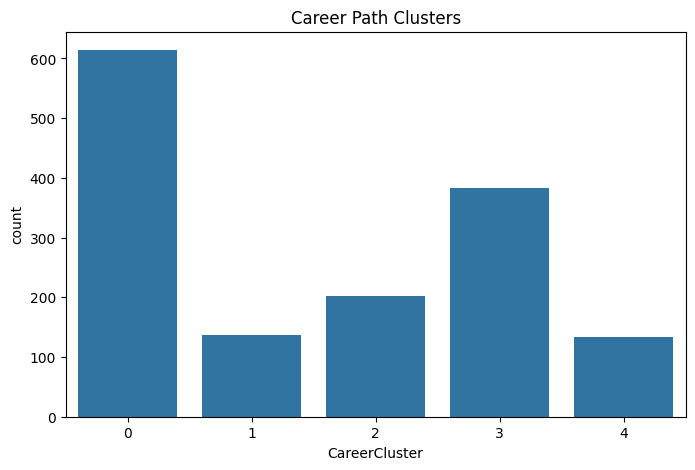

In [36]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='CareerCluster',
    data=df
)

plt.title("Career Path Clusters")

plt.show()

In [37]:
cluster_summary = df.groupby('CareerCluster')[[
    'PromotionGapRatio',
    'RoleStagnationIndex',
    'TrainingIntensityScore',
    'ManagerStability',
    'YearsAtCompany',
    'YearsSinceLastPromotion',
    'YearsInCurrentRole'
]].mean()

print(cluster_summary.round(2))

               PromotionGapRatio  RoleStagnationIndex  TrainingIntensityScore  \
CareerCluster                                                                   
0                           0.21                 0.50                    0.56   
1                           0.39                 0.47                    0.14   
2                           0.04                 0.04                    1.85   
3                           0.34                 0.70                    0.27   
4                           0.21                 0.46                    0.56   

               ManagerStability  YearsAtCompany  YearsSinceLastPromotion  \
CareerCluster                                                              
0                          0.48            4.41                     0.90   
1                          0.45           20.90                     7.93   
2                          0.02            0.82                     0.08   
3                          0.70           10.11     

In [38]:
def promotion_risk(row):

    if row['PromotionGapRatio'] > 0.60:
        return "High"

    elif row['PromotionGapRatio'] > 0.30:
        return "Medium"

    else:
        return "Low"

df['PromotionGapScore'] = df.apply(
    promotion_risk,
    axis=1
)

print(df['PromotionGapScore'].value_counts())

PromotionGapScore
Low       1006
High       254
Medium     210
Name: count, dtype: int64


In [39]:
df['RetentionOpportunityIndex'] = (
    df['PromotionGapRatio']
    +
    df['RoleStagnationIndex']
)

df[['RetentionOpportunityIndex']].head()

,RetentionOpportunityIndex
0,0.571429
1,0.727273
2,0.000000
3,1.111111
4,1.333333


In [40]:
print("===== KPI REPORT =====")

print()

print(
    "Average Promotion Gap Ratio:",
    round(df['PromotionGapRatio'].mean(),2)
)

print(
    "Average Retention Opportunity Index:",
    round(df['RetentionOpportunityIndex'].mean(),2)
)

print(
    "Average Years At Company:",
    round(df['YearsAtCompany'].mean(),2)
)

print(
    "Average Years Since Last Promotion:",
    round(df['YearsSinceLastPromotion'].mean(),2)
)

===== KPI REPORT =====

Average Promotion Gap Ratio: 0.24
Average Retention Opportunity Index: 0.72
Average Years At Company: 7.01
Average Years Since Last Promotion: 2.19


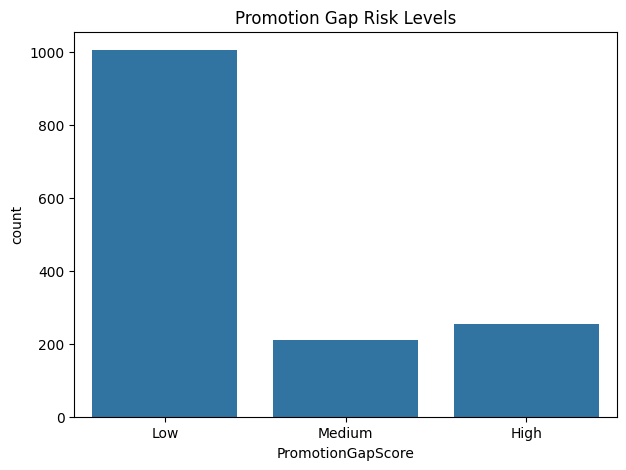

In [41]:
plt.figure(figsize=(7,5))

sns.countplot(
    x='PromotionGapScore',
    data=df
)

plt.title("Promotion Gap Risk Levels")

plt.show()

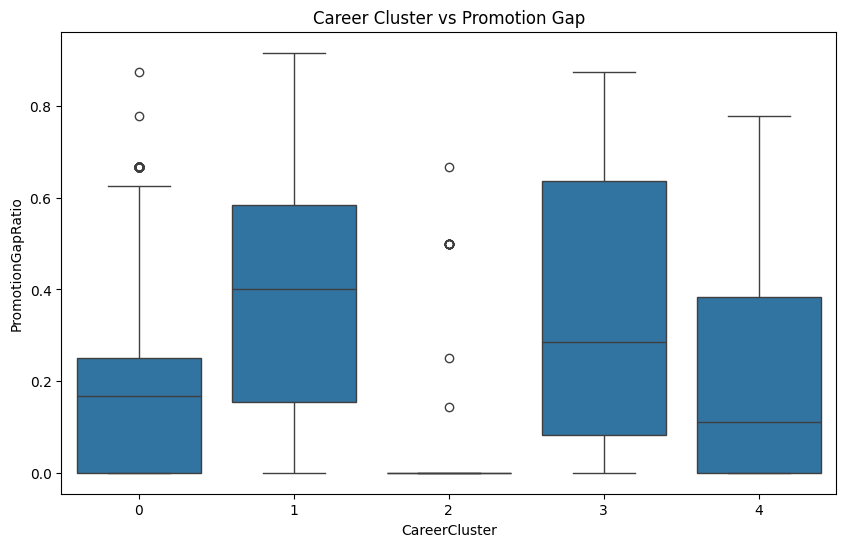

In [42]:
plt.figure(figsize=(10,6))

sns.boxplot(
    x='CareerCluster',
    y='PromotionGapRatio',
    data=df
)

plt.title(
    "Career Cluster vs Promotion Gap"
)

plt.show()

In [43]:
pca = PCA(n_components=2)

pca_data = pca.fit_transform(X_scaled)

df['PCA1'] = pca_data[:,0]

df['PCA2'] = pca_data[:,1]

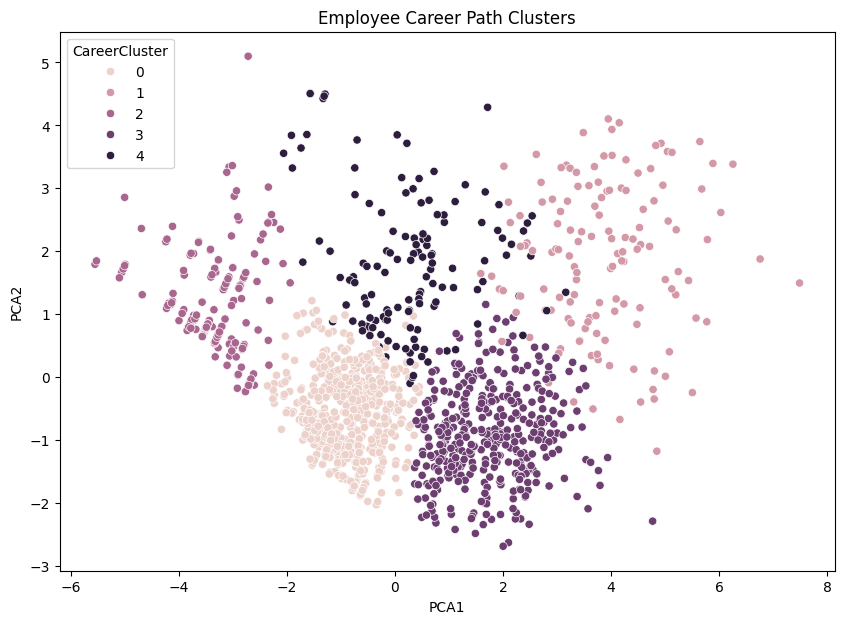

In [44]:
plt.figure(figsize=(10,7))

sns.scatterplot(
    x='PCA1',
    y='PCA2',
    hue='CareerCluster',
    data=df
)

plt.title(
    "Employee Career Path Clusters"
)

plt.show()

In [45]:
df.to_csv(
    "Career_Progression_Output.csv",
    index=False
)

print(
    "Project Completed Successfully"
)

Project Completed Successfully
